# Example: Multiple Linear Regression Estimating Fuel Efficiency

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
cars_df = pd.read_csv('https://raw.githubusercontent.com/shreyamdg/automobile-data-set-analysis/refs/heads/master/cars.csv')
cars_df.head()

,Unnamed: 0,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,3,2,164,audi,gas,std,four,sedan,fwd,front,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,4,2,164,audi,gas,std,four,sedan,4wd,front,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [10]:
cars_df.columns

Index(['Unnamed: 0', 'symboling', 'normalized-losses', 'make', 'fuel-type',
       'aspiration', 'num-of-doors', 'body-style', 'drive-wheels',
       'engine-location', 'wheel-base', 'length', 'width', 'height',
       'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size',
       'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower',
       'peak-rpm', 'city-mpg', 'highway-mpg', 'price'],
      dtype='object')

In [12]:
columns_to_keep = cars_df.columns[3:]
cars_df = cars_df[columns_to_keep]

cars_df.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Exploratory Data Analysis



## Modeling

Can we estimate fuel economy from other car specifications?

In [5]:
# Importing packages

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import root_mean_squared_error, r2_score

In [14]:
cars_df = cars_df[cars_df['fuel-type']== 'gas']
cars_df.()

,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000
mean,98.147568,173.188649,65.743243,53.496757,2518.459459,125.956757,8.860108,24.670270,30.318919
std,5.613203,12.146825,2.073558,2.409422,501.000249,42.506371,0.690242,6.311173,6.555028
min,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,94.500000,166.300000,64.000000,51.600000,2128.000000,97.000000,8.500000,19.000000,25.000000
50%,96.500000,172.600000,65.400000,53.700000,2405.000000,111.000000,9.000000,24.000000,30.000000
75%,100.400000,178.500000,66.500000,55.400000,2847.000000,141.000000,9.400000,30.000000,34.000000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,11.500000,49.000000,54.000000


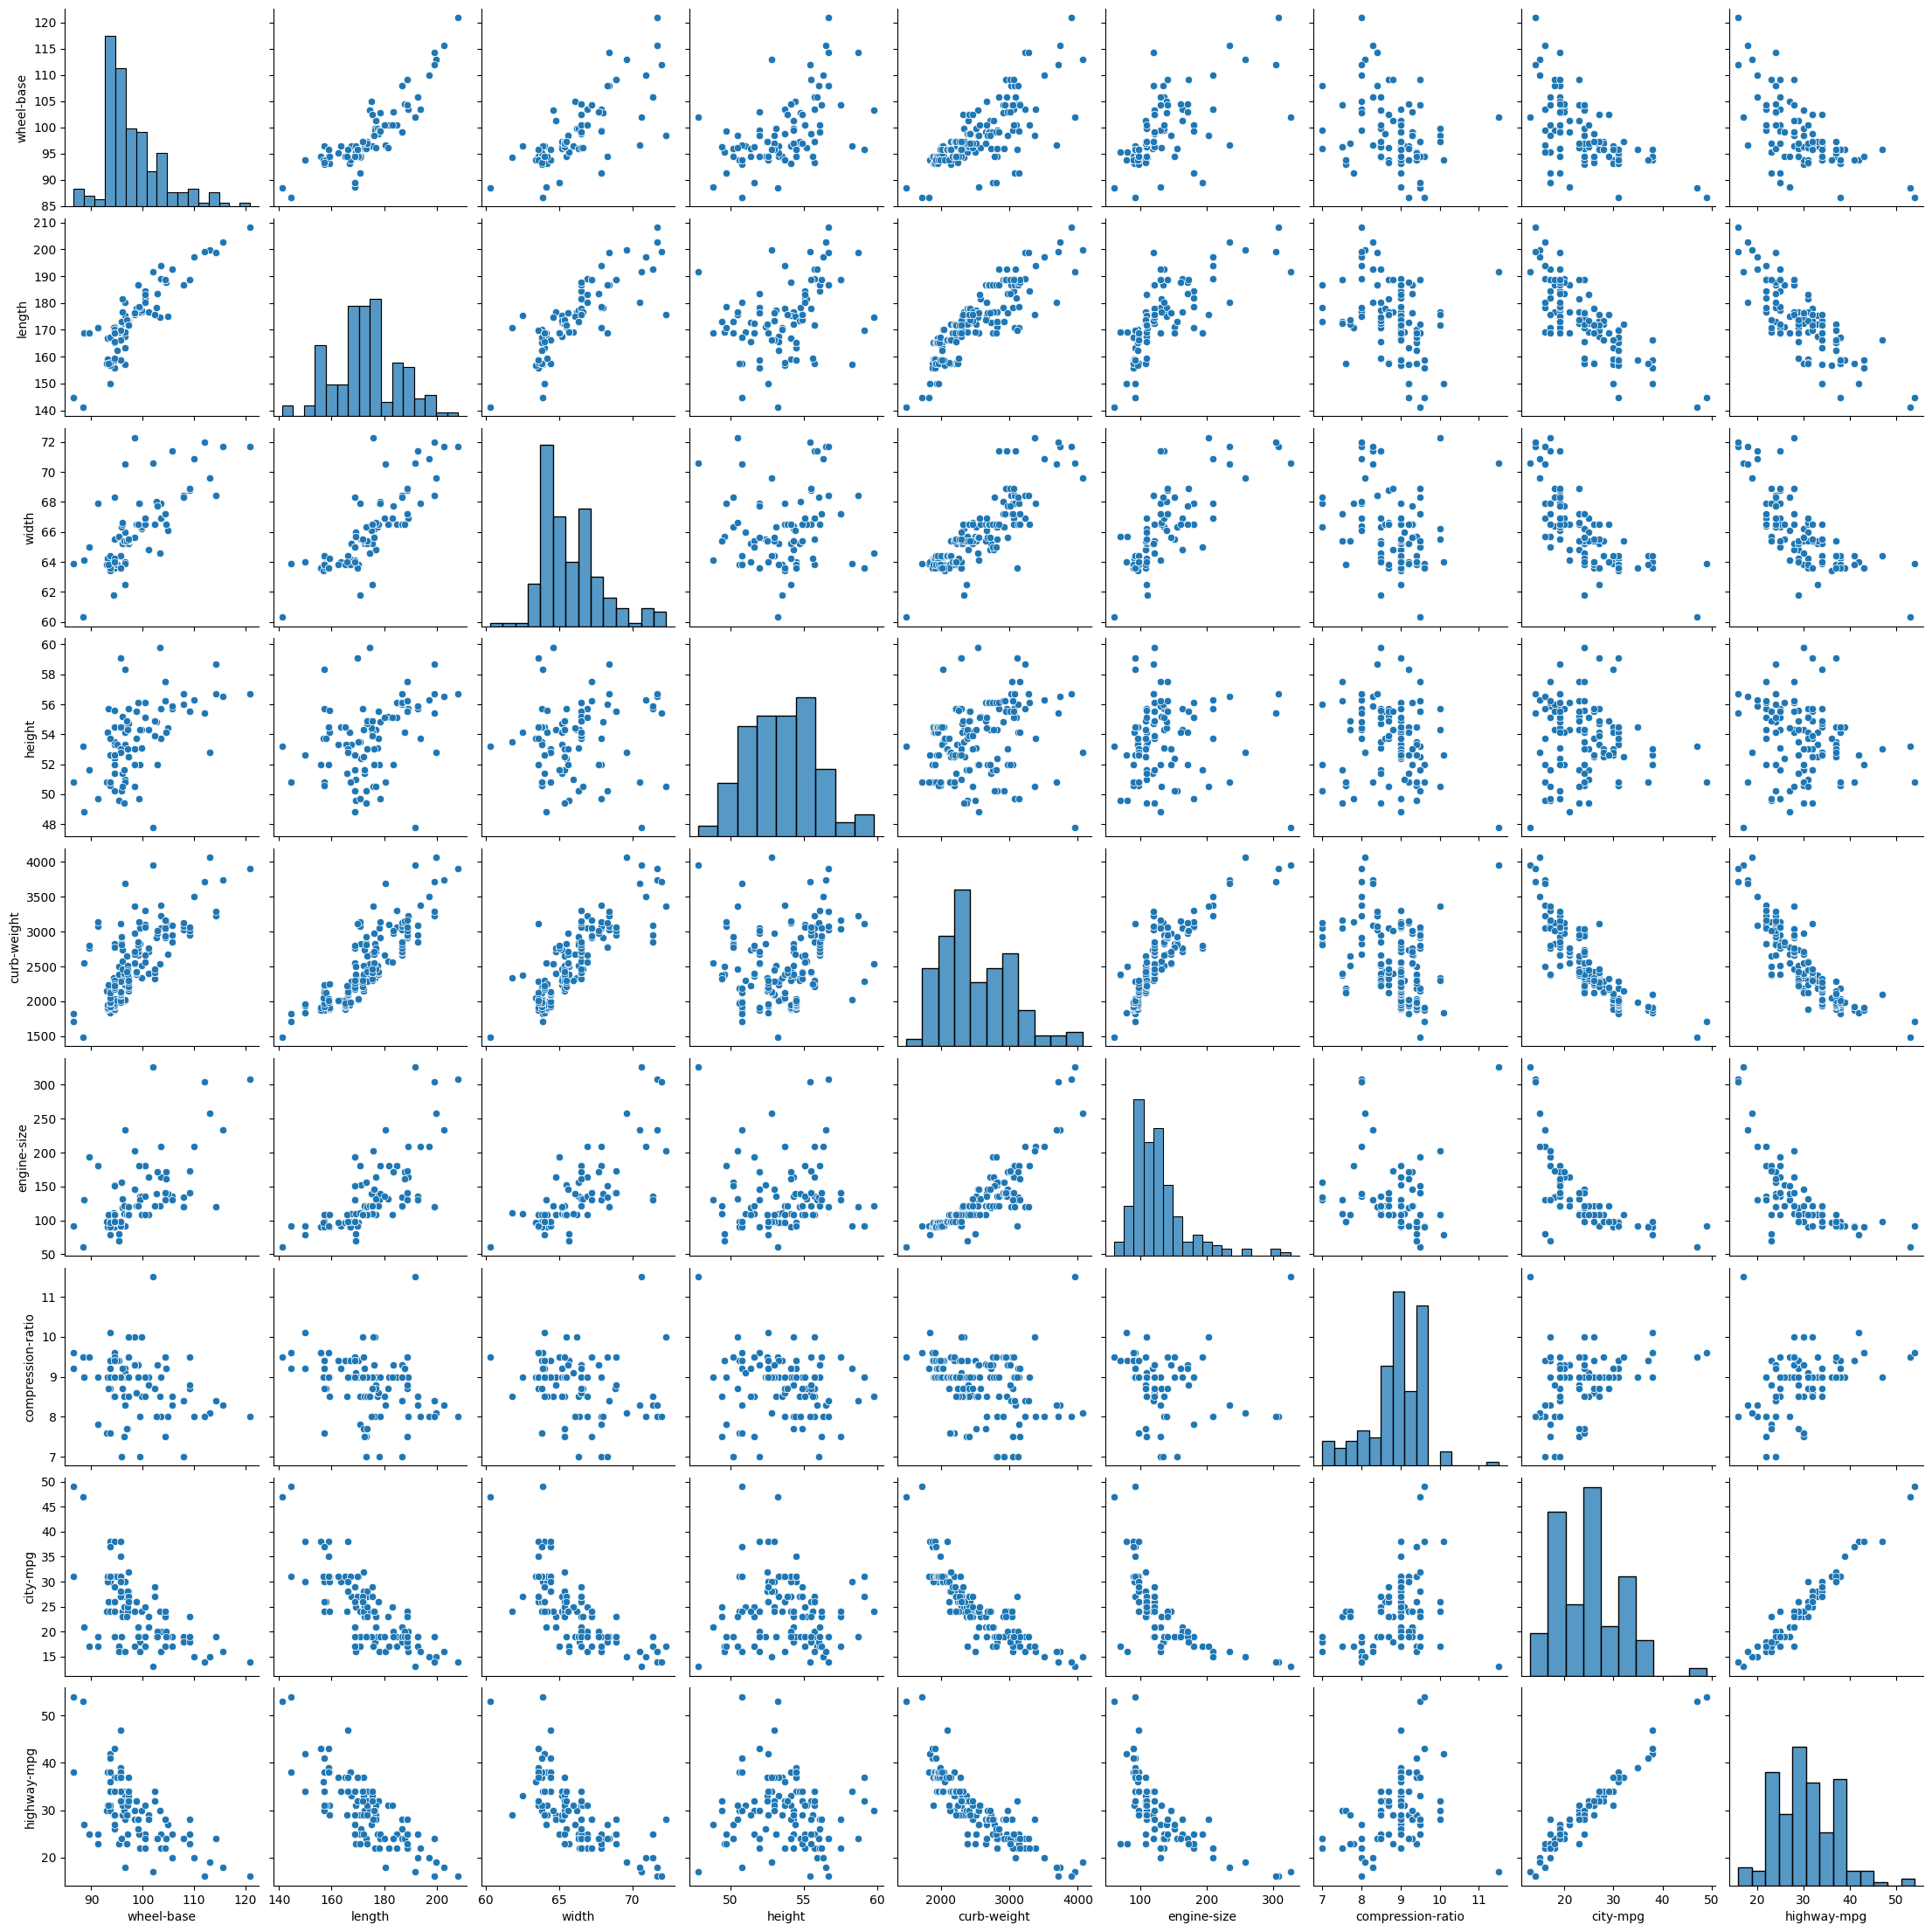

In [15]:
sns.pairplot(cars_df)
plt.show()
#Goes through numerical features and plots a scatterplot for every possible combination, histogram along same paired diagonal
#Looking for values correlated with MPG (city) -- what values look a line when paired with MPG
  #Apart from highway MPG -- Engine Size and Curb-Weight are the closest

<function matplotlib.pyplot.show(close=None, block=None)>

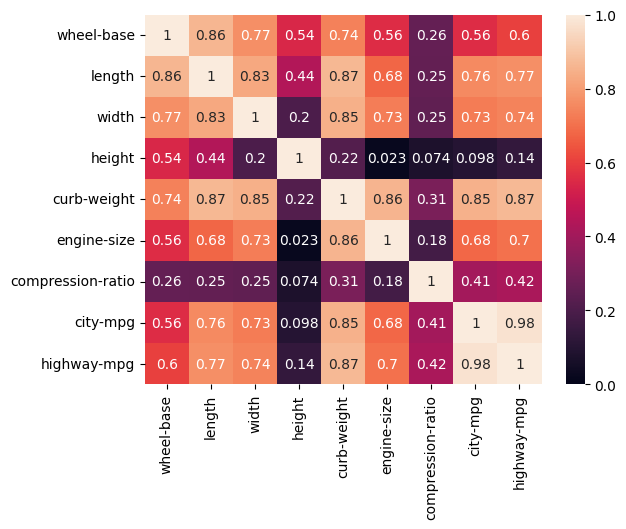

In [16]:
cars_corr = cars_df.corr(numeric_only=True)

sns.heatmap(np.abs(cars_corr), vmin=0, vmax=1, annot=True)
plt.show


In [18]:
#chose features from correlation heatmap
#Curb weight is the highest -- Don't want to keep anything that is highly correlated to curb-weight for colinearity
#Ok to use = curb-weight, compression ration, and height as features. Independent of curb-weight.

features = ['curb-weight', 'height', 'compression-ratio']
target = ['city-mpg']

X = cars_df[features]
y = cars_df[target]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #Splitting data, set aside data for testing

In [21]:
#Normalize the Data
sc = StandardScaler()

#Calculateds m, SD of X_train
sc.fit(X_train)

Z_train = sc.transform(X_train)

#Choose our model type (Linear Regression) and fit the parameters
linreg = LinearRegression()

#This fit is where we get values for theta (our parameters)
linreg.fit(Z_train, y_train)

linreg.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'n_features_in_': 3,
 'coef_': array([[-5.13003912,  0.61954832,  0.75387482]]),
 'rank_': 3,
 'singular_': array([14.70351087, 12.04319065,  9.09770998]),
 'intercept_': array([24.32432432])}

In [22]:
#Make predictions with the model

y_pred_train = linreg.predict(Z_train)

In [23]:
#Make predictions on our test data
Z_test = sc.transform(X_test)
y_pred_test = linreg.predict(Z_test)


<function matplotlib.pyplot.show(close=None, block=None)>

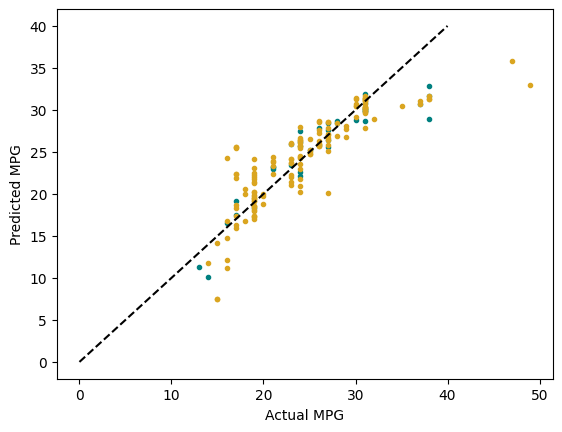

In [26]:
plt.plot(y_test, y_pred_test, '.', color = 'teal')
plt.plot(y_train, y_pred_train, '.', color = 'goldenrod')
plt.plot([0, 40], [0, 40], 'k--') #line of perfect fit
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.show